#  World Data Analysis using SQL + Pandas

##  Objective
This project analyzes global data (countries, cities, languages) using SQL queries and Pandas.

##  Tools Used
- MySQL
- Python (Pandas)
- SQLAlchemy

In [1]:
from sqlalchemy import create_engine
import pandas as pd

In [2]:
engine = create_engine("mysql+mysqlconnector://root:@localhost/world")

##  Data Preview

##  Top 5 Most Populated Countries

In [3]:
df1 = pd.read_sql_query("""
SELECT Name, Population
FROM country
ORDER BY Population DESC
LIMIT 5
""", engine)

df1

,Name,Population
0,China,1277558000
1,India,1013662000
2,United States,278357000
3,Indonesia,212107000
4,Brazil,170115000


###  Observation:
- China and India are the most populated countries
- Asian countries dominate the list

###  Conclusion:
- Population distribution is highly concentrated in Asia

##  Top 5 Most Populated Cities

In [4]:
df2=pd.read_sql_query("""
SELECT Name, Population
From city
ORDER BY Population DESC
LIMIT 5
""",engine)
df2

,Name,Population
0,Mumbai (Bombay),10500000
1,Seoul,9981619
2,São Paulo,9968485
3,Shanghai,9696300
4,Jakarta,9604900


###  Observation:
- Large cities are mostly found in developing countries

###  Conclusion:
- Urban population is growing rapidly

## Population by Continent

In [8]:
df3=pd.read_sql_query("""
SELECT Continent, SUM(Population) AS total_population
FROM country
GROUP BY Continent
ORDER BY total_population DESC
""",engine)
df3

,Continent,total_population
0,Asia,3.705026e+09
1,Africa,7.844750e+08
2,Europe,7.300746e+08
3,North America,4.829930e+08
4,South America,3.457800e+08
5,Oceania,3.040115e+07
6,Antarctica,0.000000e+00


###  Observation:
- Asia has the highest population among all continents

###  Conclusion:
- Asia is the global population hub

## Cities Count per Country

In [9]:
df4=pd.read_sql_query("""
SELECT CountryCode, Count(*) AS total_cities
FROM city
GROUP BY CountryCode
ORDER BY total_cities DESC
LIMIT 5
""",engine)
df4

,CountryCode,total_cities
0,CHN,363
1,IND,341
2,USA,274
3,BRA,250
4,JPN,248


###  Observation:
- Larger countries tend to have more cities

###  Conclusion:
- Geographic size influences urban distribution

##  Life Expectancy Analysis

In [10]:
df5=pd.read_sql_query("""
SELECT Name, LifeExpectancy
FROM country
ORDER BY LifeExpectancy DESC
LIMIT 5
""",engine)
df5

,Name,LifeExpectancy
0,Andorra,83.5
1,Macao,81.6
2,San Marino,81.1
3,Japan,80.7
4,Singapore,80.1


###  Observation:
- Developed countries have higher life expectancy

###  Conclusion:
- Better healthcare leads to longer life span

## Economic Analysis (GNP)

In [12]:
df6=pd.read_sql_query("""
SELECT Name, GNP
FROM country
ORDER BY GNP DESC
LIMIT 5
""",engine)
df6

,Name,GNP
0,United States,8510700.0
1,Japan,3787042.0
2,Germany,2133367.0
3,France,1424285.0
4,United Kingdom,1378330.0


### Observation:
- A few countries dominate global economy

###  Conclusion:
- Economic power is concentrated in limited regions

## Largest Cities with Country (JOIN)

In [13]:
df7=pd.read_sql_query("""
SELECT c.Name AS Country, ci.Name as City, ci.Population
FROM country c
JOIN city ci ON c.Code = ci.CountryCode
ORDER BY ci.Population DESC
LIMIT 5
""",engine)
df7

,Country,City,Population
0,India,Mumbai (Bombay),10500000
1,South Korea,Seoul,9981619
2,Brazil,São Paulo,9968485
3,China,Shanghai,9696300
4,Indonesia,Jakarta,9604900


###  Observation:
- Major cities belong to economically strong countries

###  Conclusion:
- Urban centers play a key role in economic growth

## Most Spoken Languages

In [14]:
df8=pd.read_sql_query("""
SELECT Language, COUNT(*) AS count
FROM countrylanguage
GROUP BY Language
ORDER BY count DESC
LIMIT 5
""",engine)
df8

,Language,count
0,English,60
1,Arabic,33
2,Spanish,28
3,French,25
4,Chinese,19


###  Observation:
- English is widely spoken across many countries

###  Conclusion:
- English acts as a global communication language

##  Cities in India

In [15]:
df9=pd.read_sql_query("""
SELECT Name, Population
FROM city
WHERE CountryCode='IND'
""",engine)
df9

,Name,Population
0,Mumbai (Bombay),10500000
1,Delhi,7206704
2,Calcutta [Kolkata],4399819
3,Chennai (Madras),3841396
4,Hyderabad,2964638
...,...,...
336,Ambala Sadar,90712
337,Baidyabati,90601
338,Morvi,90357
339,Raigarh,89166


###  Observation:
- Indian cities have high population density

###  Conclusion:
- India has densely populated urban regions

##  Average Population of Countries

In [16]:
df10=pd.read_sql_query("""
SELECT AVG(Population) AS avg_population
FROM country
""",engine)
df10

,avg_population
0,2.543410e+07


###  Conclusion:
- Provides a baseline for comparing population sizes

##  Final Conclusion

- Asia dominates global population
- Urbanization is increasing in developing countries
- Economic power is concentrated in a few nations
- English is the most widely used language

##  Learning Outcome
- Learned SQL queries (SELECT, JOIN, GROUP BY)
- Integrated SQL with Pandas
- Generated insights from real-world data

##  Data Visualization

In this section, we analyze the data using graphical representations.

In [21]:
import matplotlib.pyplot as plt

##  Top 5 Most Populated Countries

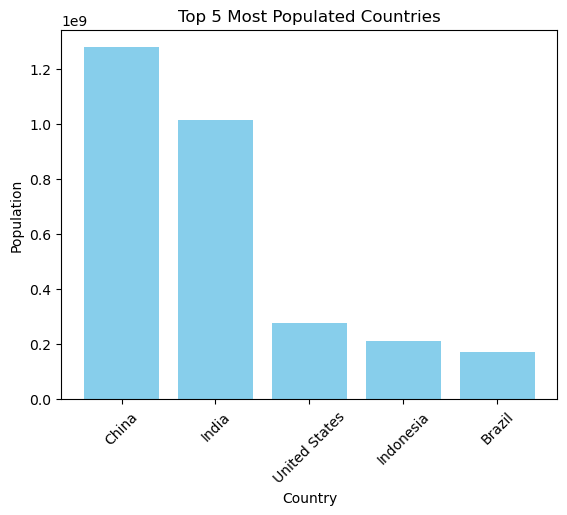

In [57]:
df_countries = pd.read_sql_query("""
SELECT Name, Population
FROM country
ORDER BY Population DESC
LIMIT 5
""", engine)

plt.figure()
plt.bar(df_countries['Name'], df_countries['Population'], color='skyblue')
plt.title("Top 5 Most Populated Countries")
plt.xlabel("Country")
plt.ylabel("Population")
plt.xticks(rotation=45)
plt.show()

###  Observation:
- China and India have significantly higher population than other countries
- Most of the top populated countries belong to Asia

###  Conclusion:
- Global population is highly concentrated in a few countries, especially in Asia

##  Population by Continent

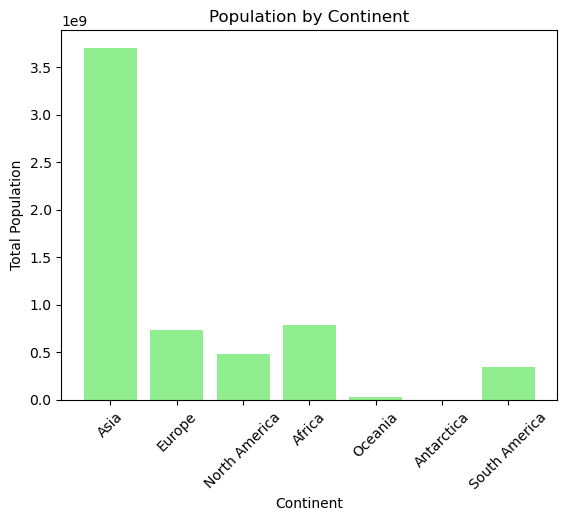

In [65]:
df_continent = pd.read_sql_query("""
SELECT Continent, SUM(Population) AS total_population
FROM country
GROUP BY Continent
""", engine)

plt.figure()
plt.bar(df_continent['Continent'], df_continent['total_population'], color='lightgreen')
plt.title("Population by Continent")
plt.xlabel("Continent")
plt.ylabel("Total Population")
plt.xticks(rotation=45)
plt.show()

###  Observation:
- Asia contributes the largest share of global population
- Europe and Africa have moderate population levels
- Other continents have comparatively smaller populations

###  Conclusion:
- Population distribution is uneven, with Asia dominating globally

##  Top 5 Cities by Population

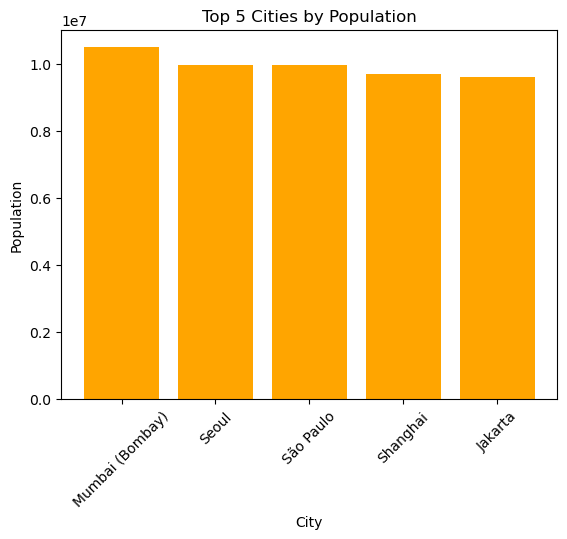

In [59]:
df_cities = pd.read_sql_query("""
SELECT Name, Population
FROM city
ORDER BY Population DESC
LIMIT 5
""", engine)

plt.figure()
plt.bar(df_cities['Name'], df_cities['Population'], color='orange')
plt.title("Top 5 Cities by Population")
plt.xlabel("City")
plt.ylabel("Population")
plt.xticks(rotation=45)
plt.show()

###  Observation:
- The most populated cities have extremely high population density
- These cities are mostly located in developing countries

###  Conclusion:
- Urban population is concentrated in major metropolitan cities

##  Most Spoken Languages

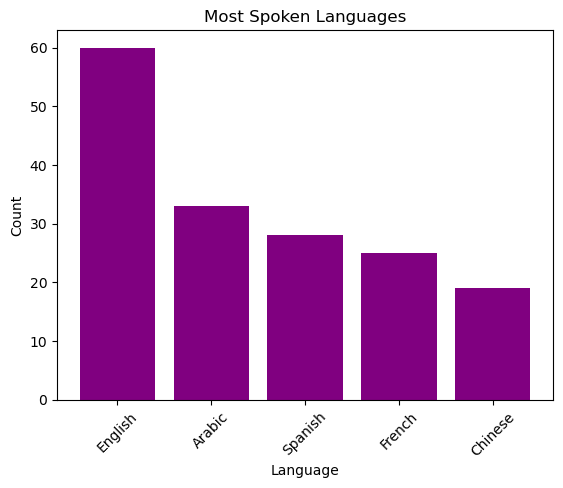

In [60]:
df_languages = pd.read_sql_query("""
SELECT Language, COUNT(*) AS count
FROM countrylanguage
GROUP BY Language
ORDER BY count DESC
LIMIT 5
""", engine)

plt.figure()
plt.bar(df_languages['Language'], df_languages['count'], color='purple')
plt.title("Most Spoken Languages")
plt.xlabel("Language")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

###  Observation:
- English appears as one of the most widely used languages
- A few languages dominate across multiple countries

###  Conclusion:
- Language distribution shows global communication is dominated by a few major languages

##  Population Distribution by Continent

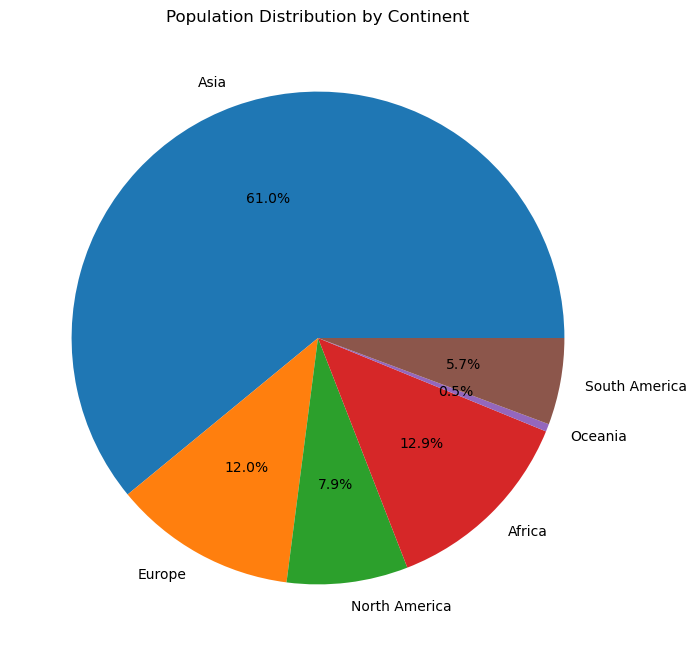

In [68]:
df_pie = pd.read_sql_query("""
SELECT Continent, SUM(Population) AS total_population
FROM country
GROUP BY Continent
""", engine)

# remove very small values
df_pie = df_pie[df_pie['total_population'] > 1000000]

plt.figure(figsize=(8,8))
plt.pie(df_pie['total_population'],
        labels=df_pie['Continent'],
        autopct='%1.1f%%',
        labeldistance=1.1)

plt.title("Population Distribution by Continent")
plt.xticks(rotation=45)
plt.show()

###  Observation:
- Asia occupies the largest portion of the pie chart
- Other continents contribute significantly less in comparison

###  Conclusion:
- A large proportion of the world’s population resides in Asia

##  Top 10 Countries by GNP

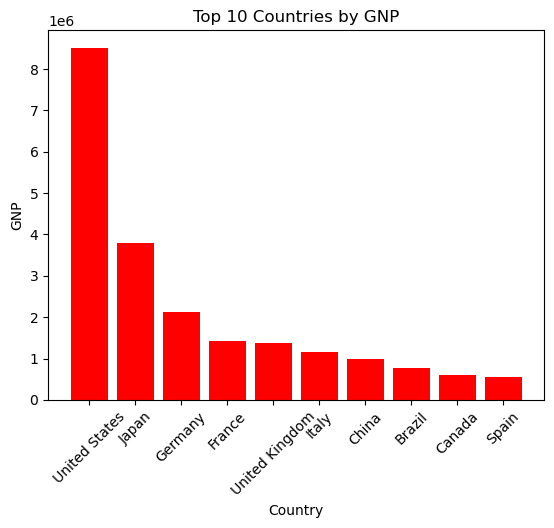

In [62]:
df_gnp = pd.read_sql_query("""
SELECT Name, GNP
FROM country
ORDER BY GNP DESC
LIMIT 10
""", engine)

plt.figure()
plt.bar(df_gnp['Name'], df_gnp['GNP'], color='red')
plt.title("Top 10 Countries by GNP")
plt.xlabel("Country")
plt.ylabel("GNP")
plt.xticks(rotation=45)
plt.show()

###  Observation:
- A small number of countries have very high GNP values
- Developed nations dominate the economic rankings

###  Conclusion:
- Global economic power is concentrated in a few developed countries

## Life Expectancy vs Population

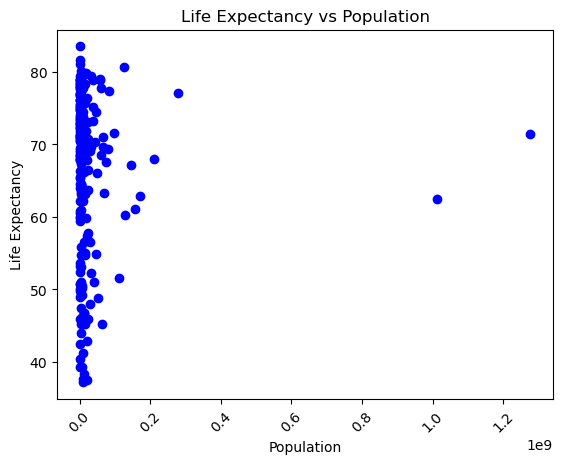

In [69]:
df_life = pd.read_sql_query("""
SELECT Population, LifeExpectancy
FROM country
WHERE LifeExpectancy IS NOT NULL
""", engine)

plt.figure()
plt.scatter(df_life['Population'], df_life['LifeExpectancy'], color='blue')
plt.title("Life Expectancy vs Population")
plt.xlabel("Population")
plt.ylabel("Life Expectancy")
plt.xticks(rotation=45)
plt.show()

###  Observation:
- No strict linear relationship but trend visible

###  Conclusion:
- Population does not directly determine life expectancy

## Number of Cities per Country

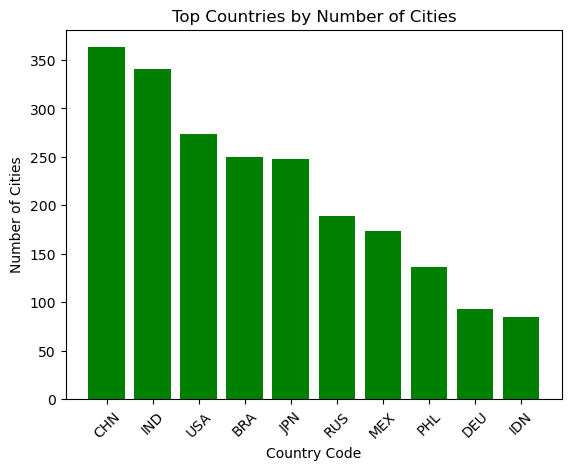

In [70]:
df_city_count = pd.read_sql_query("""
SELECT CountryCode, COUNT(*) AS total_cities
FROM city
GROUP BY CountryCode
ORDER BY total_cities DESC
LIMIT 10
""", engine)

plt.figure()
plt.bar(df_city_count['CountryCode'], df_city_count['total_cities'], color='green')
plt.title("Top Countries by Number of Cities")
plt.xlabel("Country Code")
plt.ylabel("Number of Cities")
plt.xticks(rotation=45)
plt.show()

###  Observation:
- Countries with larger geographical area tend to have more cities
- Some countries have significantly higher number of cities than others

###  Conclusion:
- The number of cities is influenced by country size and level of urbanization

##  Final Conclusion

- Asia dominates both population and urban concentration due to large countries like China and India
- Economic indicators (GNP) show that global wealth is concentrated in a few developed nations
- Language distribution highlights the importance of English as a global communication medium
- There is no direct relationship between population size and life expectancy

##  Learning Outcome
- Extracted data using SQL queries
- Performed data analysis using Pandas
- Built visual insights using Matplotlib